# **模块**: 单变量统计过程监控
## **课程**: CUSUM控制图
### *主题*:  均值漂移两倍标准差的CUSUM控制图 

In [1]:
# 导入所需包
import numpy as np
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


np.random.seed(10)

In [2]:
# ==================================================================================
#                        生成无故障样本
# ==================================================================================

> ##### 首先生成若干无故障样本作为模型训练数据集

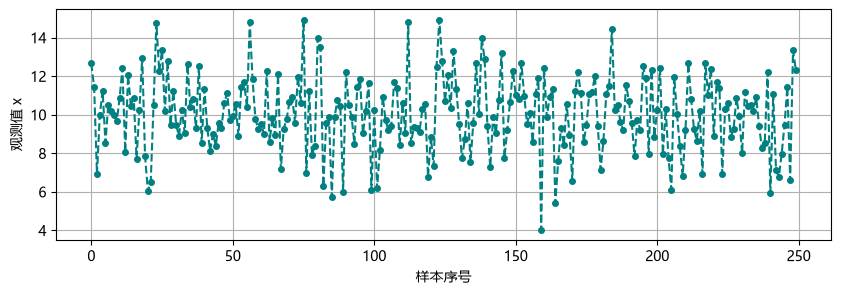

In [3]:
# 生成NOC（正常运行工况）数据
N = 250 # 250 observation samples
x_faultFree = np.random.normal(loc=10, scale=2, size=N) # mean=10; standard deviation=2

# 绘制NOC数据
plt.figure(figsize=(10,3))
plt.plot(x_faultFree,'--', marker='o', markersize=4, color='teal')
plt.xlabel('样本序号'), plt.ylabel('观测值 x')
plt.grid()
plt.show()


In [4]:
# ==================================================================================
#                                    模型训练
# ==================================================================================

> ##### 将使用NOC数据估计CUSUM控制图参数：信号的均值(mu)、标准差(sigma)以及控制限(H)

In [5]:
# 估计CUSUM模型参数并为NOC数据绘制控制图
mu, sigma = np.mean(x_faultFree), np.std(x_faultFree)
k = 0.25*sigma
H = 5*sigma

print(f'CUSUM 控制图控制限：{H}')

CUSUM 控制图控制限：9.765931343973723


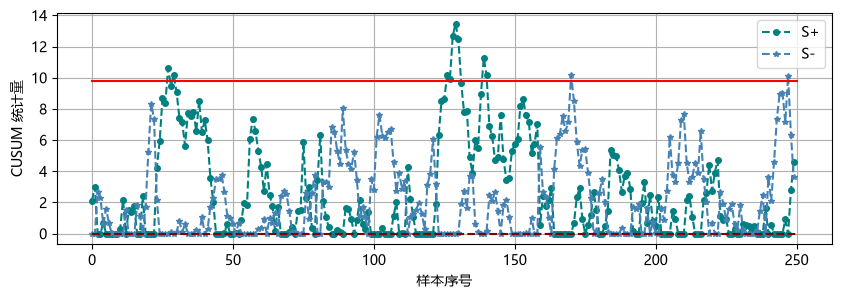

In [6]:
# 计算NOC数据的CUSUM统计量
S_positive = np.zeros((N,))
S_negative = np.zeros((N,))

for i in range(N):
    if i==0:
        S_positive[i] = np.max([0, x_faultFree[i]-(mu+k)])
        S_negative[i] = np.max([0, (mu-k)-x_faultFree[i]])  
    else:
        S_positive[i] = np.max([0, x_faultFree[i]-(mu+k) + S_positive[i-1]])
        S_negative[i] = np.max([0, (mu-k)-x_faultFree[i] + S_negative[i-1]])

# 绘制NOC数据控制图
plt.figure(figsize=(10,3))
plt.plot(S_positive,'--',marker='o', markersize=4, color='teal', label='S+')
plt.plot(S_negative,'--',marker='*', markersize=4, color='steelblue', label='S-')
plt.plot([0,N],[H,H], color='red')
plt.plot([0,N],[0,0], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('CUSUM 统计量')
plt.grid(), plt.legend()
plt.show()

In [7]:
# ==================================================================================
#               生成故障测试样本并绘制在控制图上
# ==================================================================================

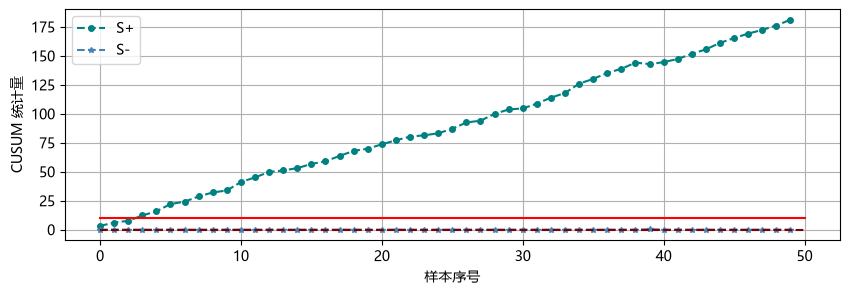

In [8]:
# 故障数据
N_faulty = 50 # 50 observation samples
x_faulty = np.random.normal(loc=14, scale=2, size=N_faulty) # mean=10+0.5*2; standard deviation=2

# 测试数据的CUSUM统计量
S_positive_test = np.zeros((N_faulty,))
S_negative_test = np.zeros((N_faulty,))

for i in range(N_faulty):
    if i==0:
        S_positive_test[i] = np.max([0, x_faulty[i]-(mu+k)])
        S_negative_test[i] = np.max([0, (mu-k)-x_faulty[i]]) 
    else:
        S_positive_test[i] = np.max([0, x_faulty[i]-(mu+k) + S_positive_test[i-1]])
        S_negative_test[i] = np.max([0, (mu-k)-x_faulty[i] + S_negative_test[i-1]])

# 绘制测试数据控制图
plt.figure(figsize=(10,3))
plt.plot(S_positive_test,'--',marker='o', markersize=4, color='teal', label='S+')
plt.plot(S_negative_test,'--',marker='*', markersize=4, color='steelblue', label='S-')
plt.plot([0,N_faulty],[H,H], color='red')
plt.plot([0,N_faulty],[0,0], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('CUSUM 统计量')
plt.grid(), plt.legend()
plt.show()

In [9]:
# ==================================================================================
#         所有样本（无故障与故障）合并的控制图
# ==================================================================================

In [10]:
# # 合并数据
x_combined = np.hstack((x_faultFree, x_faulty))
print(f'无故障样本 x_faultfree 形状 = {x_faultFree.shape}')
print(f'故障样本 x_faulty 形状 = {x_faulty.shape}')
print(f'合并样本 x_combined 形状 = {x_combined.shape}')

无故障样本 x_faultfree 形状 = (250,)
故障样本 x_faulty 形状 = (50,)
合并样本 x_combined 形状 = (300,)


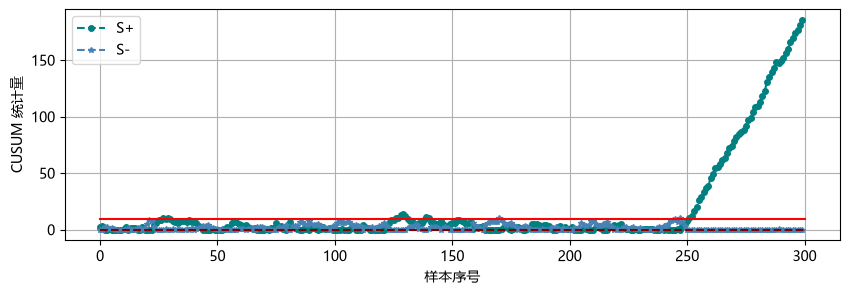

In [11]:
# 合并数据的CUSUM统计量与控制图
S_positive = np.zeros((len(x_combined),))
S_negative = np.zeros((len(x_combined),))

for i in range(len(x_combined)):
    if i==0:
        S_positive[i] = np.max([0, x_combined[i]-(mu+k)])
        S_negative[i] = np.max([0, (mu-k)-x_combined[i]]) 
    else:
        S_positive[i] = np.max([0, x_combined[i]-(mu+k) + S_positive[i-1]])
        S_negative[i] = np.max([0, (mu-k)-x_combined[i] + S_negative[i-1]])

plt.figure(figsize=(10,3))
plt.plot(S_positive,'--',marker='o', markersize=4, color='teal', label='S+')
plt.plot(S_negative,'--',marker='*', markersize=4, color='steelblue', label='S-')
plt.plot([0,len(x_combined)],[H,H], color='red')
plt.plot([0,len(x_combined)],[0,0], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('CUSUM 统计量')
plt.grid()
plt.legend()
plt.show()